In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data.csv")

df.columns = [col.strip().replace(" ", "_").replace("/", "_") for col in df.columns]

df['Date_Time'] = pd.to_datetime(df['Date_Time'], errors='coerce')

df = df.sort_values('Date_Time').dropna().reset_index(drop=True)

In [3]:
# Time
df['hour'] = df['Date_Time'].dt.hour
df['day'] = df['Date_Time'].dt.day
df['month'] = df['Date_Time'].dt.month
df['season'] = (df['month'] % 12 + 3) // 3

# Physical
df['temp_dew_diff'] = df['Temp_C'] - df['Dew_Point_Temp_C']
df['humidity_temp'] = df['Rel_Hum_%'] * df['Temp_C']
df['pressure_change'] = df['Press_kPa'].diff()

# Weather
df['is_fog'] = df['Weather'].str.contains("Fog", case=False).astype(int)
df = pd.concat([df, df['Weather'].str.get_dummies(sep=',')], axis=1)

df = df.dropna()

In [4]:
for lag in [1,2,3,6,12,24,48]:
    df[f'vis_lag_{lag}'] = df['Visibility_km'].shift(lag)

df['vis_roll_mean_6'] = df['Visibility_km'].rolling(6).mean()
df['vis_roll_mean_12'] = df['Visibility_km'].rolling(12).mean()
df['vis_roll_std_6'] = df['Visibility_km'].rolling(6).std()

df = df.dropna().reset_index(drop=True)

In [5]:
target = 'Visibility_km'

drop_cols = ['Date_Time', 'Weather']
features = [col for col in df.columns if col not in drop_cols + [target]]

X = df[features]
y = df[target]

In [6]:
split_index = int(len(df) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [7]:
tscv = TimeSeriesSplit(n_splits=5)

In [8]:
xgb = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

param_grid_xgb = {
    'n_estimators': [400, 600],
    'max_depth': [6, 8],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'gamma': [0, 0.1]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=tscv,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [9]:
xgb_preds = best_xgb.predict(X_test)

print("XGB R2:", r2_score(y_test, xgb_preds))
print("MAE:", mean_absolute_error(y_test, xgb_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_preds)))

XGB R2: 0.9104742902493058
MAE: 1.5196728823180872
RMSE: 3.116280715914326


In [13]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    n_estimators=600,
    learning_rate=0.05,

    max_depth=8,             # (avoid -1)
    num_leaves=31,           # controls complexity

    min_child_samples=20,    # prevents useless splits

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,           # L1 regularization
    reg_lambda=0.1,          # L2 regularization

    random_state=42,
    verbose=-1
)

param_grid_lgb = {
    'n_estimators': [400, 600],
    'learning_rate': [0.03, 0.05],
    'num_leaves': [31, 64],
    'max_depth': [-1, 10],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

grid_lgb = GridSearchCV(
    lgb,
    param_grid_lgb,
    cv=tscv,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid_lgb.fit(X_train, y_train)

best_lgb = grid_lgb.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [14]:
lgb_preds = best_lgb.predict(X_test)

print("LGB R2:", r2_score(y_test, lgb_preds))

LGB R2: 0.9041978188255617


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Final fixed model (no tuning)
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train, y_train)

# Predict
rf_preds = rf.predict(X_test)

# Evaluate
print("RF R2:", r2_score(y_test, rf_preds))
print("RF MAE:", mean_absolute_error(y_test, rf_preds))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))

RF R2: 0.8828441456594505
RF MAE: 1.9245709561044826
RF RMSE: 3.564878097241211


In [18]:
stack = StackingRegressor(
    estimators=[
        ('xgb', best_xgb),
        ('lgb', best_lgb),
        ('rf', rf)
    ],
    final_estimator=Ridge()
)

stack.fit(X_train, y_train)

stack_preds = stack.predict(X_test)

print("STACK R2:", r2_score(y_test, stack_preds))
print("MAE:", mean_absolute_error(y_test, stack_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, stack_preds)))

STACK R2: 0.9102339625835384
MAE: 1.5163957507250545
RMSE: 3.1204606689684287


In [20]:
import joblib

joblib.dump(stack, "visibility_stack_model.pkl")

['visibility_stack_model.pkl']

In [22]:
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "RandomForest", "Stacking"],
    "R2": [r2_score(y_test, xgb_preds), r2_score(y_test, lgb_preds), r2_score(y_test, rf_preds), r2_score(y_test, stack_preds)]
})

print(results)

          Model        R2
0       XGBoost  0.910474
1      LightGBM  0.904198
2  RandomForest  0.882844
3      Stacking  0.910234


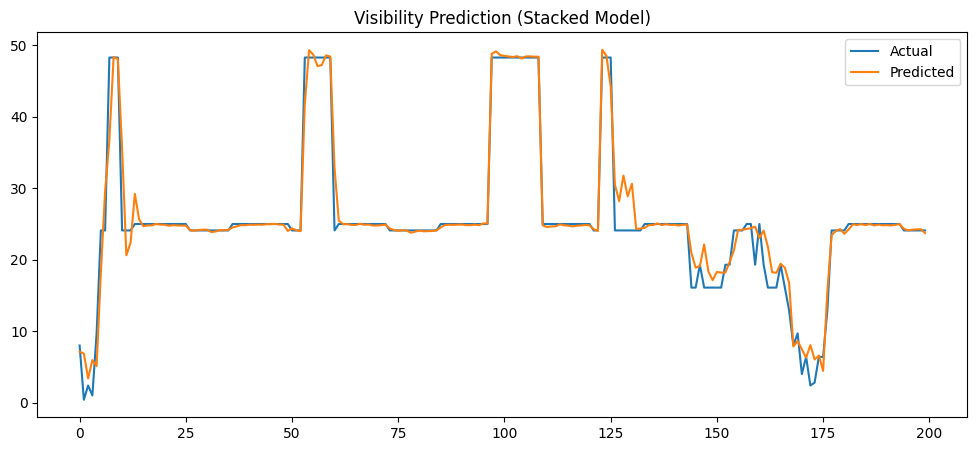

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(stack_preds[:200], label="Predicted")
plt.legend()
plt.title("Visibility Prediction (Stacked Model)")
plt.show()

In [24]:
model = joblib.load("visibility_stack_model.pkl")

In [25]:
preds = model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))

R2: 0.9102339625835384
MAE: 1.5163957507250545
RMSE: 3.1204606689684287


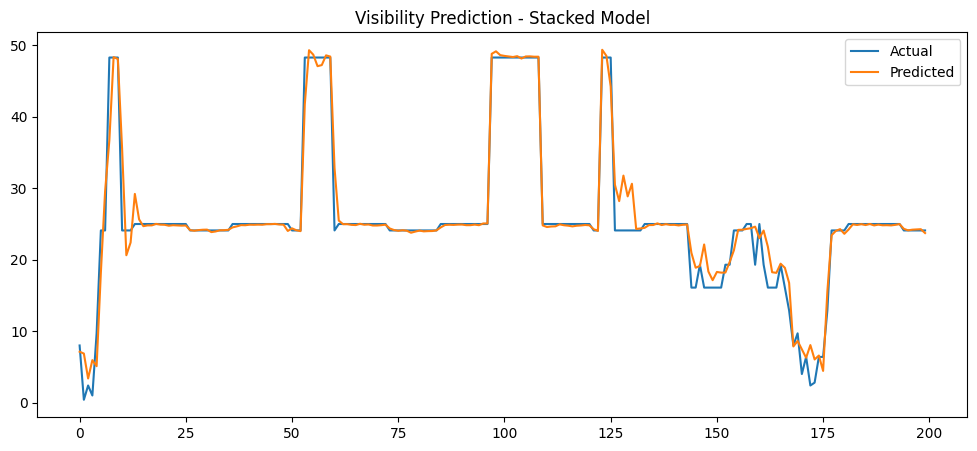

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(preds[:200], label="Predicted")
plt.legend()
plt.title("Visibility Prediction - Stacked Model")
plt.show()

In [30]:
from IPython.display import display

sample = X_test.iloc[[0]]

print("INPUT SAMPLE:")
display(sample)

prediction = model.predict(sample)

print("\nPredicted Visibility (km):", prediction[0])

INPUT SAMPLE:


,Temp_C,Dew_Point_Temp_C,Rel_Hum_%,Wind_Speed_km_h,Press_kPa,hour,day,month,season,temp_dew_diff,...,vis_lag_1,vis_lag_2,vis_lag_3,vis_lag_6,vis_lag_12,vis_lag_24,vis_lag_48,vis_roll_mean_6,vis_roll_mean_12,vis_roll_std_6
6988,12.5,12.0,97,4,99.84,5,20,10,4,0.5,...,11.3,6.4,4.8,16.1,6.4,19.3,25.0,8.833333,12.066667,4.187919



Predicted Visibility (km): 7.1268171651927865


In [32]:
from IPython.display import display

# take one real sample
sample_input = X_test.iloc[[0]].copy()

# modify selected raw features (safe edits)
sample_input.loc[:, 'Temp_C'] = 10
sample_input.loc[:, 'Rel_Hum_%'] = 90
sample_input.loc[:, 'Wind_Speed_km_h'] = 5

# show input nicely as table
print(" Modified Input Sample:")
display(sample_input)

# prediction
pred = model.predict(sample_input)

print("\nPredicted Visibility (km):", pred[0])

 Modified Input Sample:


,Temp_C,Dew_Point_Temp_C,Rel_Hum_%,Wind_Speed_km_h,Press_kPa,hour,day,month,season,temp_dew_diff,...,vis_lag_1,vis_lag_2,vis_lag_3,vis_lag_6,vis_lag_12,vis_lag_24,vis_lag_48,vis_roll_mean_6,vis_roll_mean_12,vis_roll_std_6
6988,10.0,12.0,90,5,99.84,5,20,10,4,0.5,...,11.3,6.4,4.8,16.1,6.4,19.3,25.0,8.833333,12.066667,4.187919



Predicted Visibility (km): 7.408511445900039
